In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Part 1 — Exploratory Data Analysis
This part focuses on understanding the dataset before building charts. The goal is to inspect the structure, identify missing values, and prepare the data for deeper analysis.

## 1.1 Dataset Overview
The Titanic dataset records the survival outcomes of passengers aboard the RMS Titanic. It contains demographic, socioeconomic, and ticket-related information that can help explain survival patterns.

## Q1 — Initial Inspection

In [3]:
# (a) Display first 8 rows and last 5 rows
display(df.head(8))
display(df.tail(5))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [4]:
# (b) Shape, data types, numeric summary, categorical summary
print("Shape of dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nNumeric summary:")
display(df.describe())

print("\nCategorical summary:")
display(df.describe(include='object'))

Shape of dataset: (891, 15)

Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Numeric summary:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Categorical summary:


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [5]:
# (c) Missing values: count and percentage
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
display(missing_summary.sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


# (c) Missing values: count and percentage
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
display(missing_summary.sort_values(by='Missing Percentage', ascending=False))

In [6]:
# (d) Overall survival rate and survival rate by pclass
overall_survival = df['survived'].mean()

survival_by_class = (
    df.groupby('pclass')['survived']
    .mean()
    .reset_index()
    .rename(columns={'survived': 'survival_rate'})
)

overall_df = pd.DataFrame({
    'Metric': ['Overall Survival Rate'],
    'Value': [overall_survival]
})

display(overall_df)
display(survival_by_class)

,Metric,Value
0,Overall Survival Rate,0.383838


,pclass,survival_rate
0,1,0.629630
1,2,0.472826
2,3,0.242363


### Interpretation

The overall survival rate is well below 50%, which shows that most passengers did not survive.  
When survival is broken down by passenger class, first-class passengers show the highest survival rate, while third-class passengers show the lowest. This suggests that socioeconomic status and ticket class played a strong role in survival chances.

## Q2 — Data Cleaning & Feature Engineering
The next step is to clean the dataset and create useful derived features for analysis.

In [7]:
# Make a working copy
df_clean = df.copy()

In [8]:
# (a) Impute missing age using group median by sex and pclass
df_clean['age'] = df_clean.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)

df_clean['age'].isnull().sum()

np.int64(0)

### Age Imputation Justification

I used group-based median imputation by sex and pclass because age is likely related to both gender and ticket class.  
This is more meaningful than using one overall median for the entire dataset. A limitation is that imputation reduces natural variation and may hide unusual age patterns within groups.

In [9]:
# (b) Drop deck
df_clean = df_clean.drop(columns=['deck'])

### Why Drop `deck`?

The `deck` column contains too many missing values, so imputing it would introduce too much uncertainty.  
Since most of the entries are absent, dropping the column is more reliable than trying to guess missing deck information.

In [10]:
# (c) Fill missing embarked and embark_town with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

df_clean[['embarked', 'embark_town']].isnull().sum()

embarked       0
embark_town    0
dtype: int64

In [11]:
# (d) Create family_size and travel_group
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

def classify_group(x):
    if x == 1:
        return 'Solo'
    elif 2 <= x <= 4:
        return 'Small'
    else:
        return 'Large'

df_clean['travel_group'] = df_clean['family_size'].apply(classify_group)

df_clean['travel_group'].value_counts()

travel_group
Solo     537
Small    292
Large     62
Name: count, dtype: int64

In [12]:
# (e) Create age_group
bins = [0, 12, 17, 59, np.inf]
labels = ['Child', 'Teen', 'Adult', 'Senior']

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_clean[['age', 'age_group']].head()

,age,age_group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


In [13]:
# (f) Final null check for columns used forward
columns_used = [
    'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
    'embarked', 'embark_town', 'family_size', 'travel_group', 'age_group'
]

final_null_check = df_clean[columns_used].isnull().sum()
display(final_null_check[final_null_check > 0])

Series([], dtype: int64)

### Cleaning Summary

After the cleaning process:
- missing `age` values were imputed,
- `deck` was removed,
- missing embarkation values were filled,
- new features `family_size`, `travel_group`, and `age_group` were created.

The columns used in the later analysis now have no missing values.

# Part 2 — Univariate Analysis & Distributions
This part studies one variable at a time to understand shape, spread, skewness, and category balance.

## Q3 — Age Distribution Deep-Dive

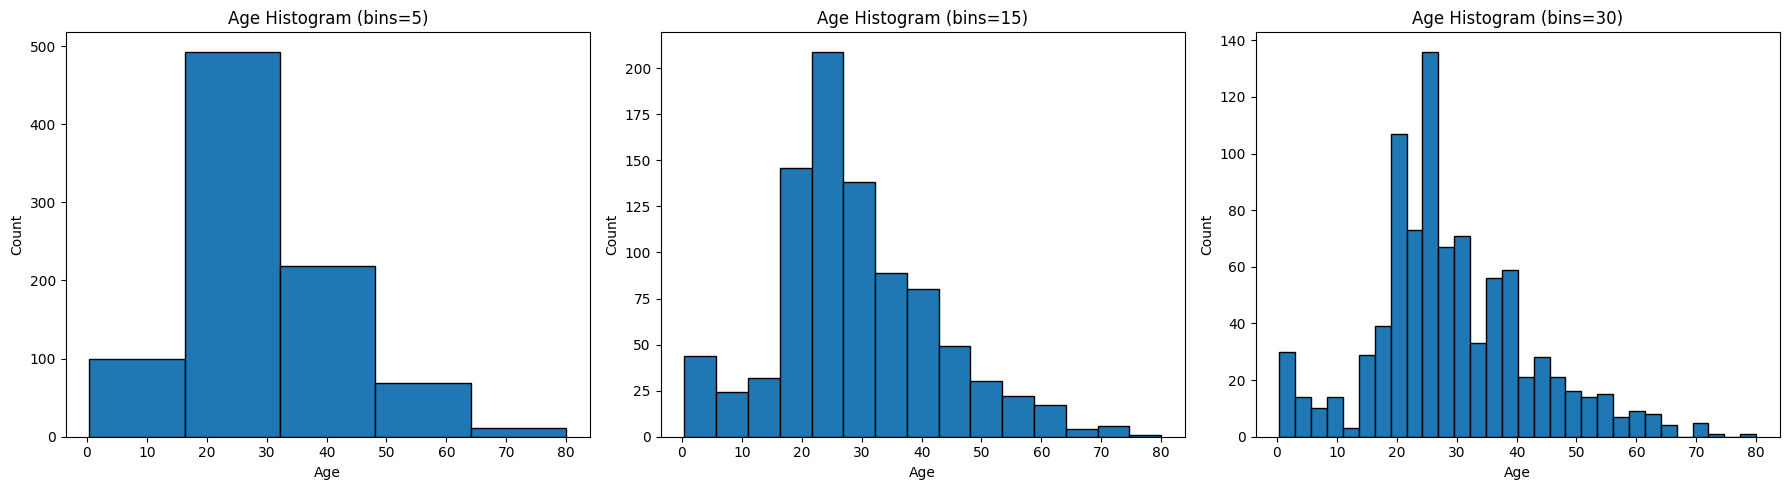

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, bins in zip(axes, [5, 15, 30]):
    ax.hist(df_clean['age'], bins=bins, edgecolor='black')
    ax.set_title(f'Age Histogram (bins={bins})')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### Bin Size Interpretation

- **5 bins:** This over-smooths the data because too much detail is lost and the age structure looks overly simplified.
- **15 bins:** This is approximately right because it shows the overall distribution clearly without making it too noisy.
- **30 bins:** This begins to under-smooth because the plot becomes too jagged and small fluctuations may appear more important than they are.

The best choice is **15 bins** because it balances clarity and detail.

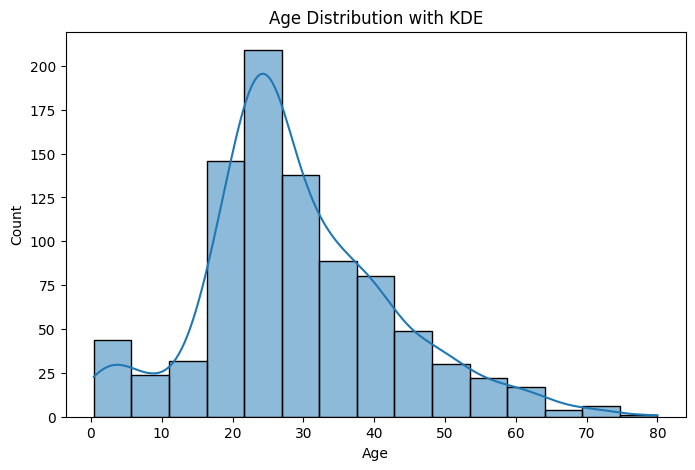

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='age', bins=15, kde=True)
plt.title('Age Distribution with KDE')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Interpretation

The age distribution is slightly right-skewed, with more passengers concentrated in younger and middle-adult age ranges.  
It is not perfectly symmetric and appears to have multiple small peaks, which may reflect different subgroups of passengers such as children, young adults, and older adults.  
The presence of many adults and fewer elderly passengers is consistent with the demographic makeup of ship travelers in that era.

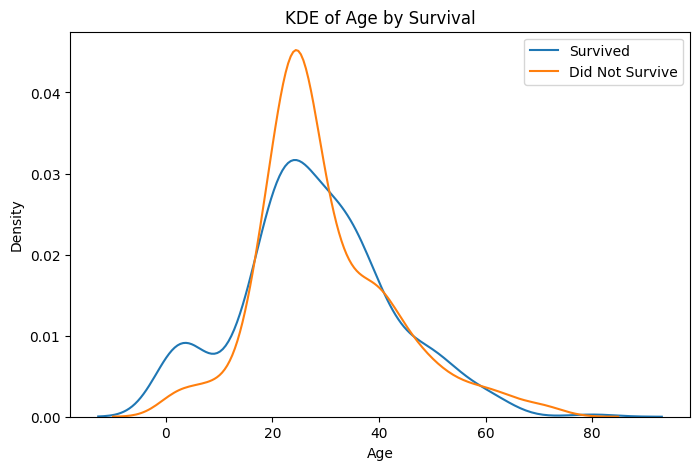

In [16]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_clean[df_clean['survived'] == 1], x='age', label='Survived', fill=False)
sns.kdeplot(data=df_clean[df_clean['survived'] == 0], x='age', label='Did Not Survive', fill=False)
plt.title('KDE of Age by Survival')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

### Interpretation

The survivor and non-survivor curves differ noticeably in younger age ranges, especially among children, where survival appears higher.  
Another difference appears among adult males, where non-survival is much more concentrated.  
This likely reflects evacuation priorities such as “women and children first.”

## Q4 — Fare Analysis

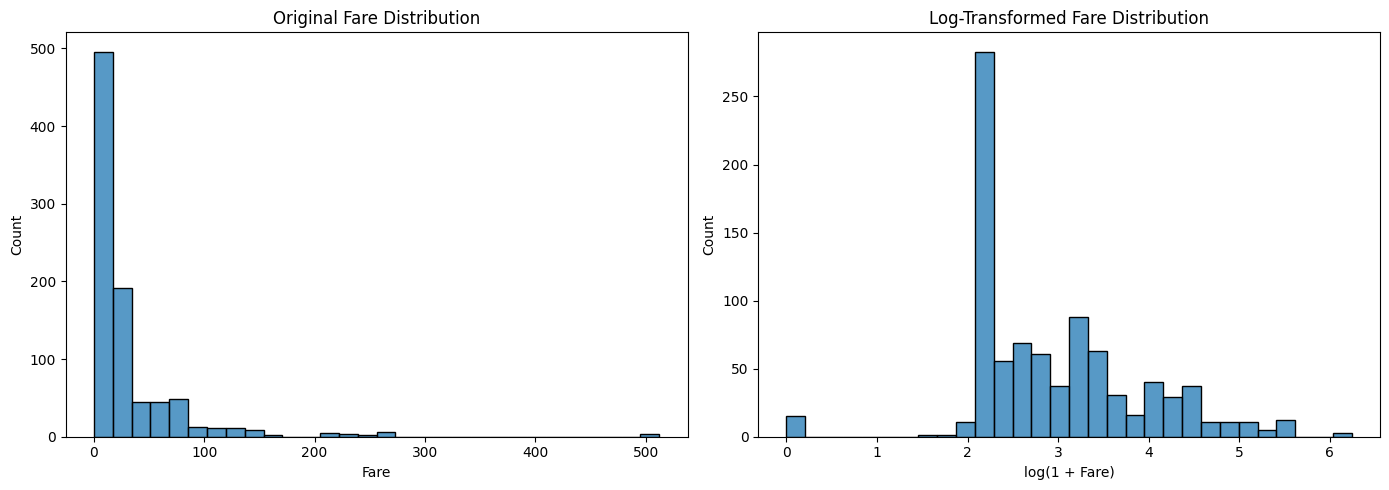

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['fare'], bins=30, ax=axes[0])
axes[0].set_title('Original Fare Distribution')
axes[0].set_xlabel('Fare')

sns.histplot(np.log1p(df_clean['fare']), bins=30, ax=axes[1])
axes[1].set_title('Log-Transformed Fare Distribution')
axes[1].set_xlabel('log(1 + Fare)')

plt.tight_layout()
plt.show()

### Interpretation

The original fare distribution is highly right-skewed, with many low fares and a few extremely high values.  
After applying the log transformation, the distribution becomes less skewed and easier to interpret because the extreme values no longer dominate the chart.  
The transformed plot is more informative because it makes the structure of the majority of observations clearer.

In [18]:
# (b) Identify extreme fare outliers > 300
fare_outliers = df_clean[df_clean['fare'] > 300]
print("Number of fare outliers above 300:", len(fare_outliers))
display(fare_outliers[['survived', 'pclass', 'sex', 'fare', 'embarked', 'class']])

Number of fare outliers above 300: 3


,survived,pclass,sex,fare,embarked,class
258,1,1,female,512.3292,C,First
679,1,1,male,512.3292,C,First
737,1,1,male,512.3292,C,First


### Interpretation

These outliers appear to be legitimate premium fares rather than obvious data errors.  
They are likely associated with first-class passengers, special cabin arrangements, or large family/group bookings. Their presence is realistic given the class-based fare structure on the Titanic.

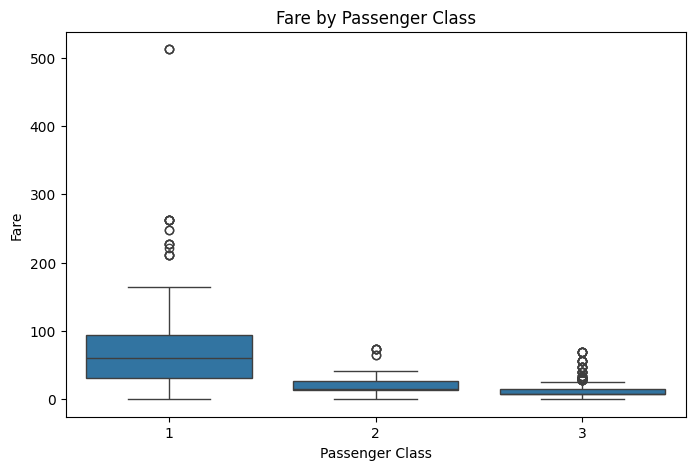

In [19]:
# (c) Box plot of fare by pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='pclass', y='fare')
plt.title('Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

### Interpretation

First class has the greatest spread in fare values and also contains the most extreme outliers.  
Third class fares are much lower and more compressed.  
This suggests that ticket pricing was strongly stratified by class, with first class offering a wider range of premium fare options.

## Q5 — Categorical Distributions

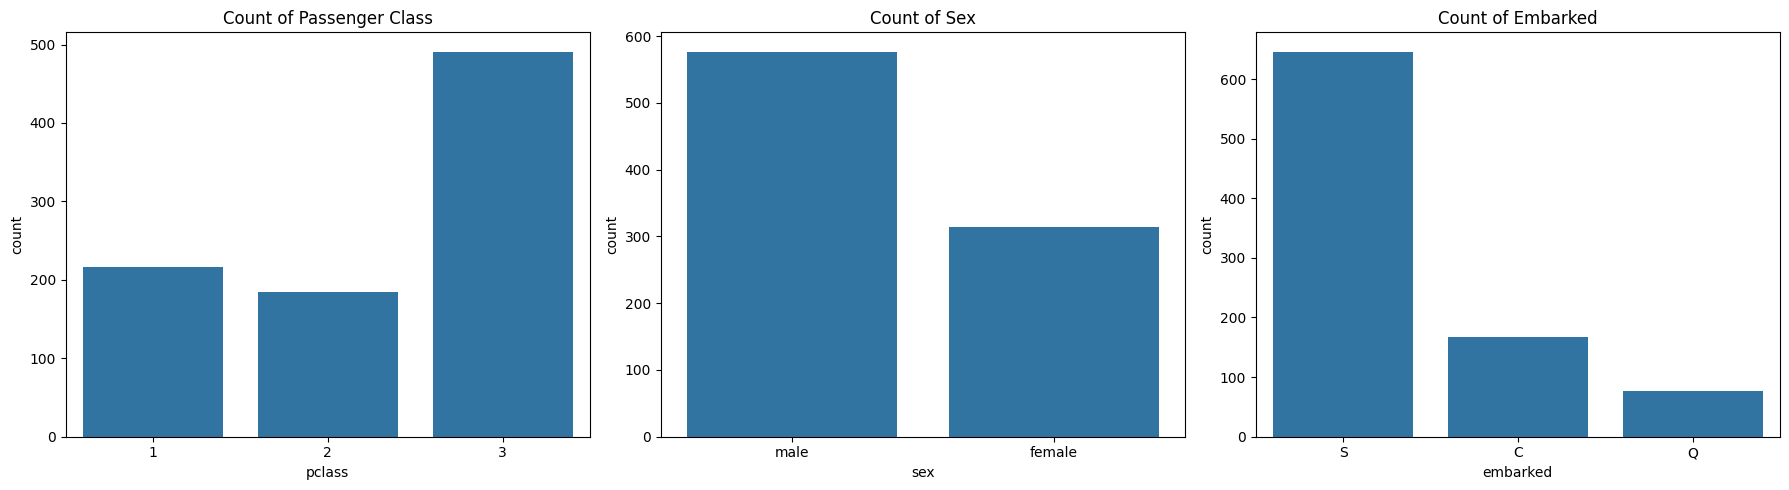

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_clean, x='pclass', ax=axes[0])
axes[0].set_title('Count of Passenger Class')

sns.countplot(data=df_clean, x='sex', ax=axes[1])
axes[1].set_title('Count of Sex')

sns.countplot(data=df_clean, x='embarked', ax=axes[2])
axes[2].set_title('Count of Embarked')

plt.tight_layout()
plt.show()

### One Observation Per Chart

- **pclass:** Third-class passengers make up the largest group in the dataset.
- **sex:** Male passengers are more numerous than female passengers.
- **embarked:** Most passengers boarded from Southampton (`S`), making it the dominant embarkation point.

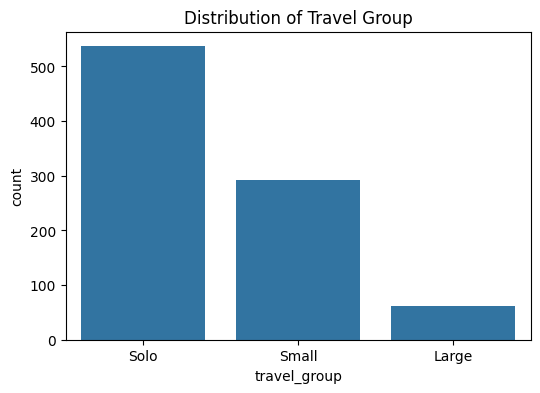

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='travel_group', order=['Solo', 'Small', 'Large'])
plt.title('Distribution of Travel Group')
plt.show()

### Interpretation

Travelling solo is the norm rather than the exception, since the `Solo` category appears most frequent.

In [ ]:
age_order = ['Child', 'Teen', 'Adult', 'Senior']
age_counts = df_clean['age_group'].value_counts().reindex(age_order)

plt.figure(figsize=(6, 4))
sns.barplot(x=age_counts.index, y=age_counts.values)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

### Interpretation

Adults are by far the most represented age group in the dataset, while seniors and teens are the least represented.  
This indicates that the passenger population was dominated by working-age adults.

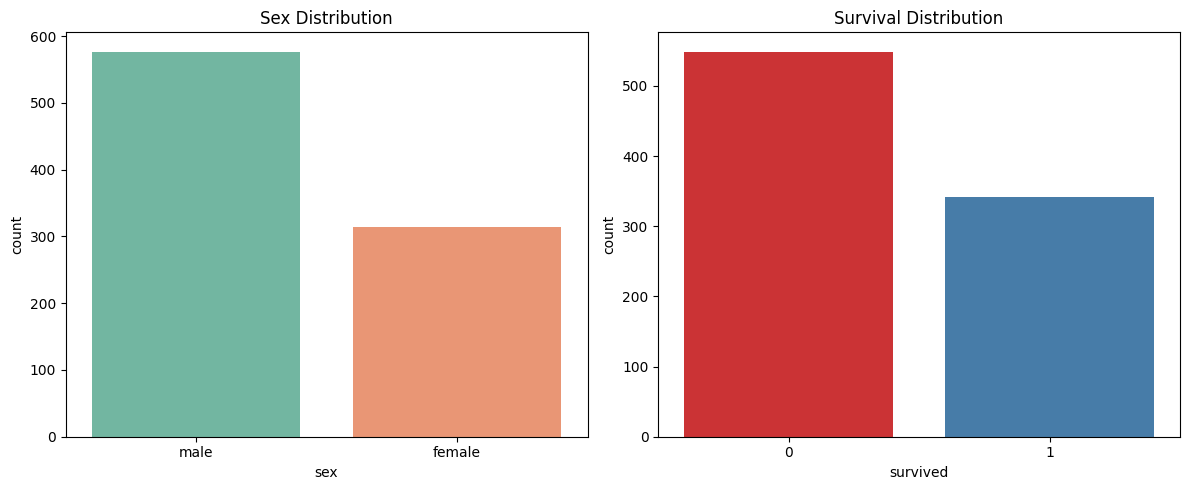

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_clean, x='sex', ax=axes[0], palette='Set2')
axes[0].set_title('Sex Distribution')

sns.countplot(data=df_clean, x='survived', ax=axes[1], palette='Set1')
axes[1].set_title('Survival Distribution')

plt.tight_layout()
plt.show()

### Interpretation

Count plots alone are not enough to compare survival chances because they show totals, not proportions.  
A group may have more survivors in count simply because it has more people overall. Survival rate charts are more appropriate for comparing chances across groups.